# Look at Data from 0 transaction costs two-sided assymetry pilot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import pdb

from clean_data import clean_data, reshape_raw_bargaining_data, equilibrium_payoff, plot_bargaining_rounds, clean_zero_TA_costs_two_sided_data

In [2]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/DataCollection130052025/all_apps_wide-2025-05-14.csv")


df_one_sided_TA_costs = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/data/Data_Collection_03_04_2025/raw_data.csv")
df_one_sided_clean = clean_data(df_one_sided_TA_costs)

In [3]:
df_clean = clean_zero_TA_costs_two_sided_data(df)
df_clean.shape

/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/analysis_03042025/clean_data.py:82: RuntimeWarning: divide by zero encountered in divide
  tmp = pd.Series(payoff / gft)
/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/src/bargaining_analysis/analysis_03042025/clean_data.py:82: RuntimeWarning: invalid value encountered in divide
  tmp = pd.Series(payoff / gft)


(240, 89)

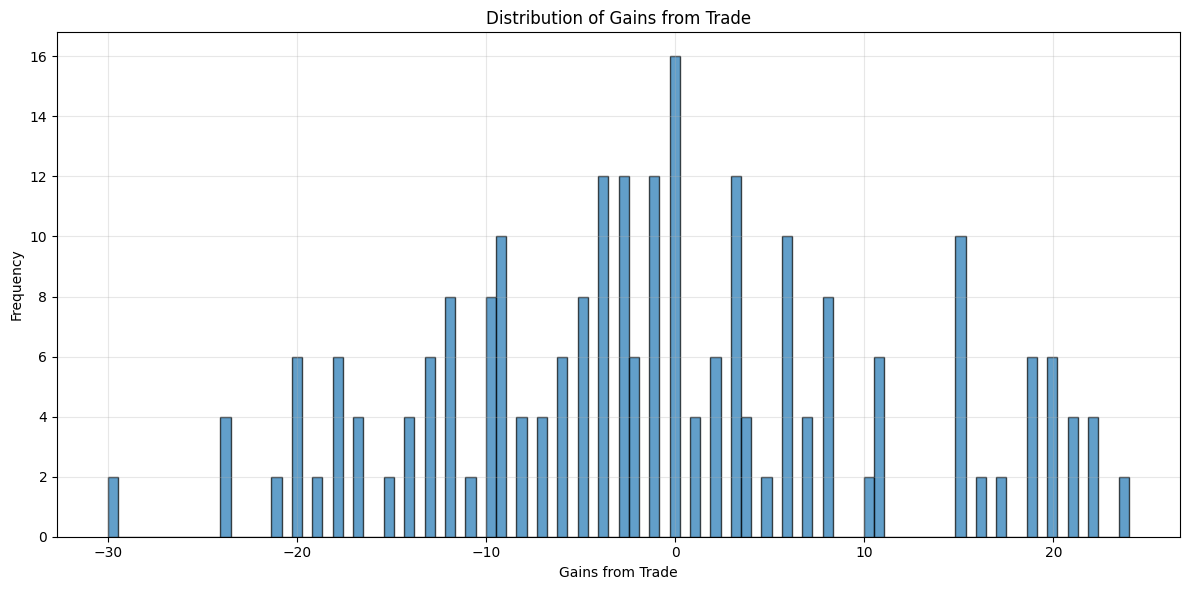

Number of gains from trade greater than 0: 94
Number of gains from trade less than 0: 130


In [4]:
plt.figure(figsize=(12, 6))

# Create histogram
plt.hist(df_clean['gains_from_trade'], bins=100, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Gains from Trade')
plt.xlabel('Gains from Trade')
plt.ylabel('Frequency')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and print the number of gains from trade greater than 0 and less than 0
greater_than_zero = (df_clean['gains_from_trade'] > 0).sum()
less_than_zero = (df_clean['gains_from_trade'] < 0).sum()

print(f"Number of gains from trade greater than 0: {greater_than_zero}")
print(f"Number of gains from trade less than 0: {less_than_zero}")

# Plot Bargaining Rounds

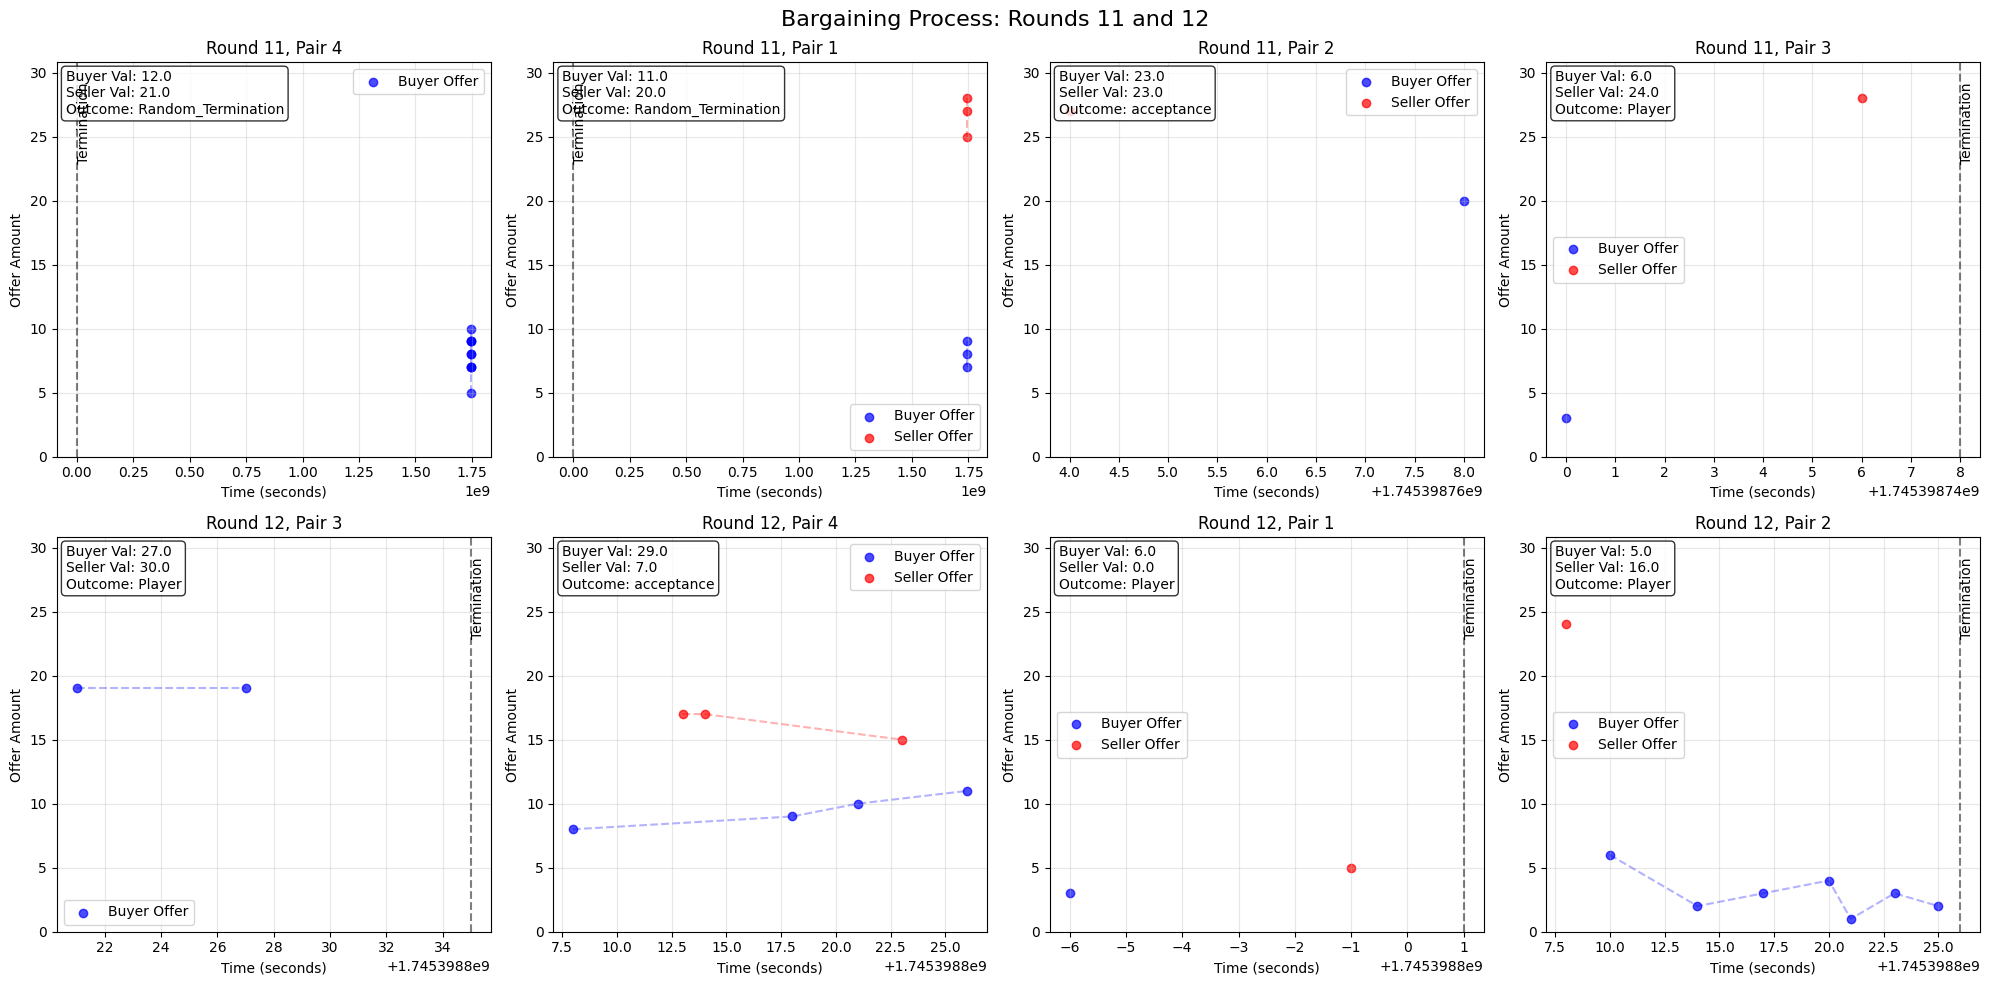

In [5]:
plot_bargaining_rounds(df_clean, 11, 12)

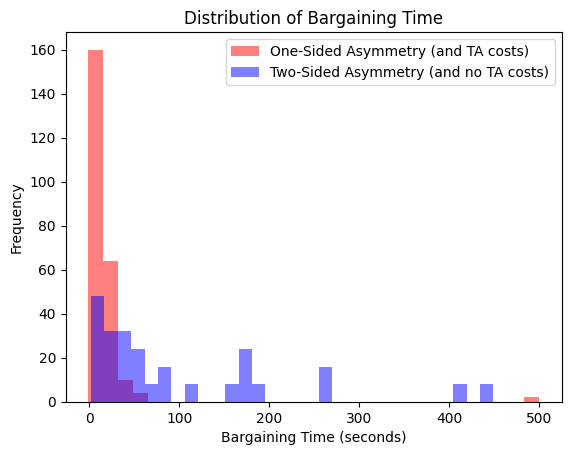

In [8]:
plt.hist(df_one_sided_clean['bargaining_duration_sec'], bins=30, alpha=0.5, label='One-Sided Asymmetry (and TA costs)', color='red')
plt.hist(df_clean['bargaining_time_correct'], bins=30, alpha=0.5, label='Two-Sided Asymmetry (and no TA costs)', color='blue')

# Add title and legend
plt.title('Distribution of Bargaining Time')
plt.xlabel('Bargaining Time (seconds)')
plt.ylabel('Frequency')
plt.legend()


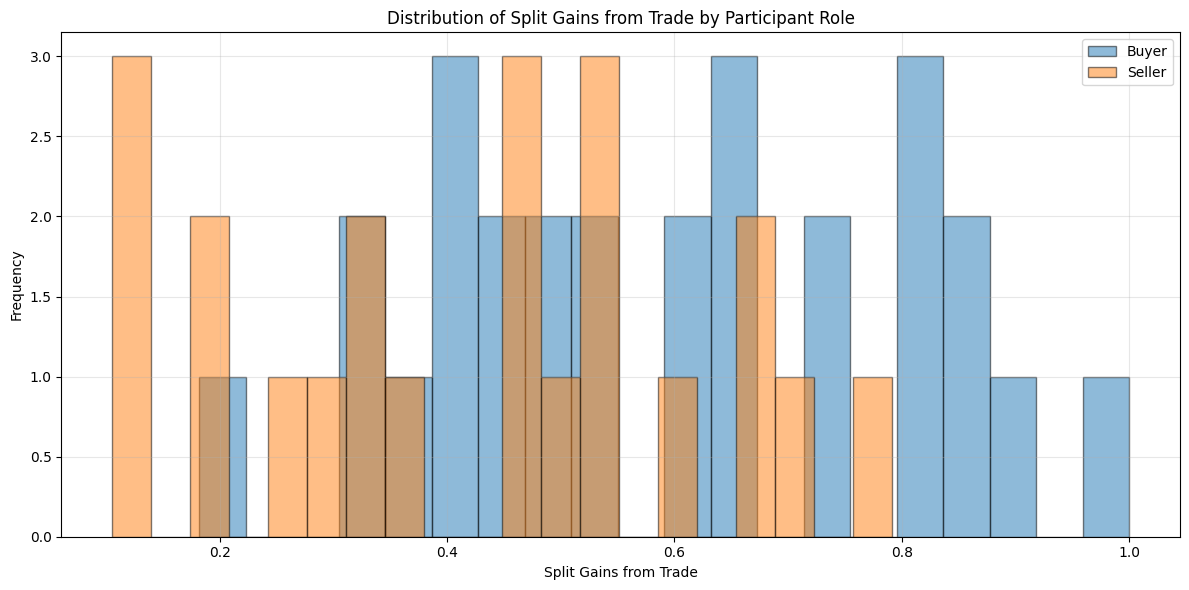

In [10]:
plt.figure(figsize=(12, 6))

# Create histograms for 'Buyer' and 'Seller' with only values greater than 0
for role in ['Buyer', 'Seller']:
    role_data = df_clean[(df_clean['participant_role'] == role) & (df_clean['split_gains_from_trade'] > 0) & (df_clean['split_gains_from_trade'] <= 1)]
    plt.hist(role_data['split_gains_from_trade'], bins=20, alpha=0.5, label=f'{role}', edgecolor='black')

# Add labels and title
plt.title('Distribution of Split Gains from Trade by Participant Role')
plt.xlabel('Split Gains from Trade')
plt.ylabel('Frequency')

# Add legend
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


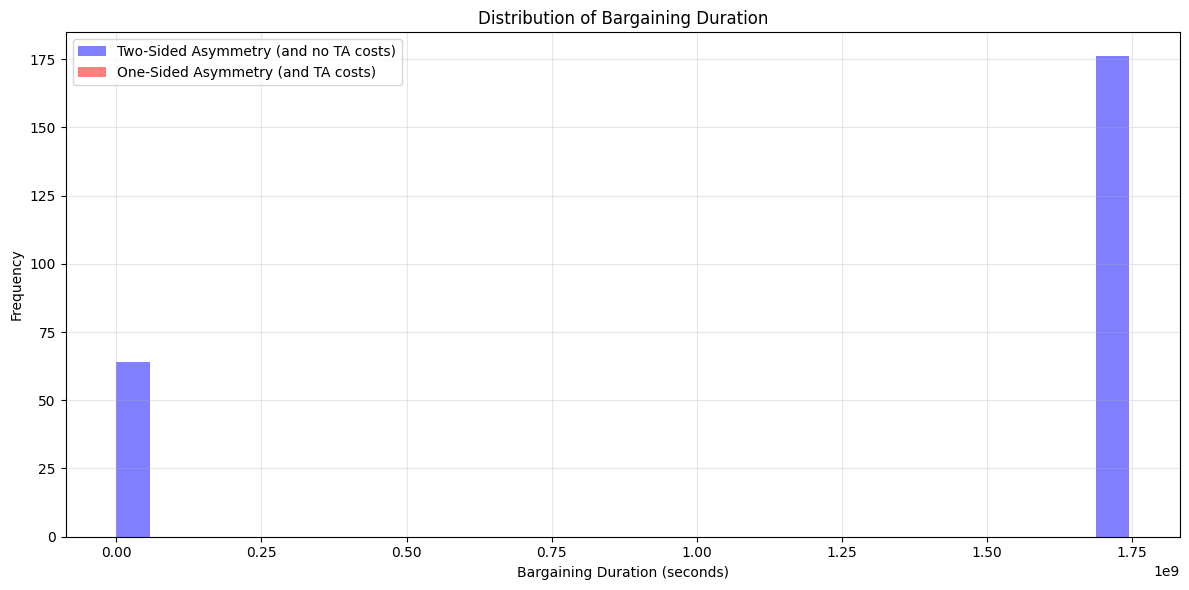

In [27]:
plt.figure(figsize=(12, 6))

# Create histograms for both datasets
plt.hist(df_clean['bargaining_duration_sec'], bins=30, alpha=0.5, label='Two-Sided Asymmetry (and no TA costs)', color='blue')
plt.hist(df_one_sided_clean['bargaining_duration_sec'], bins=30, alpha=0.5, label='One-Sided Asymmetry (and TA costs)', color='red')

# Add labels and title
plt.title('Distribution of Bargaining Duration')
plt.xlabel('Bargaining Duration (seconds)')
plt.ylabel('Frequency')

# Add legend
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

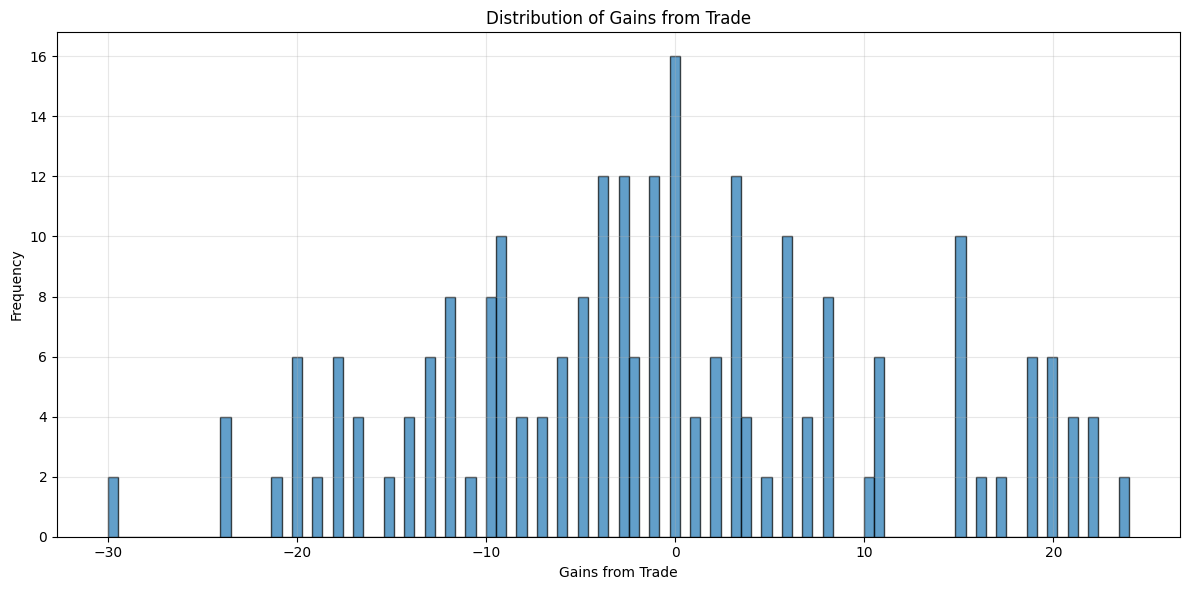

Number of gains from trade greater than 0: 94
Number of gains from trade less than 0: 130


In [ ]:
plt.figure(figsize=(12, 6))

# Create histogram
plt.hist(df_clean['gains_from_trade'], bins=100, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Gains from Trade')
plt.xlabel('Gains from Trade')
plt.ylabel('Frequency')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and print the number of gains from trade greater than 0 and less than 0
greater_than_zero = (df_clean['gains_from_trade'] > 0).sum()
less_than_zero = (df_clean['gains_from_trade'] < 0).sum()

print(f"Number of gains from trade greater than 0: {greater_than_zero}")
print(f"Number of gains from trade less than 0: {less_than_zero}")

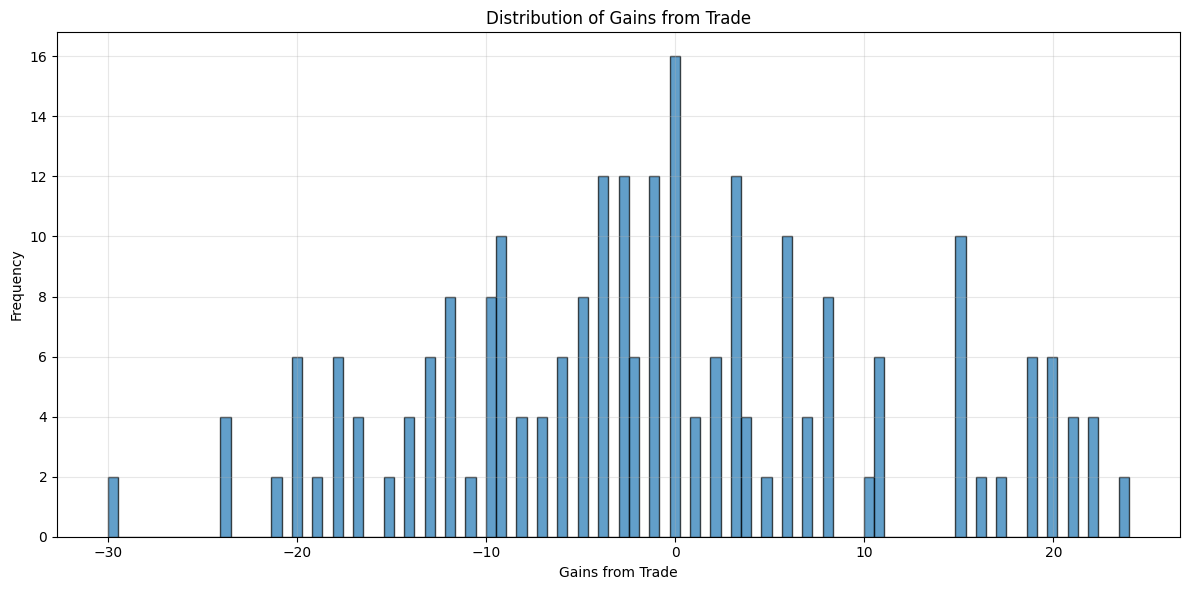

Number of gains from trade greater than 0: 94
Number of gains from trade less than 0: 130


In [ ]:
plt.figure(figsize=(12, 6))

# Create histogram
plt.hist(df_clean['gains_from_trade'], bins=100, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Gains from Trade')
plt.xlabel('Gains from Trade')
plt.ylabel('Frequency')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and print the number of gains from trade greater than 0 and less than 0
greater_than_zero = (df_clean['gains_from_trade'] > 0).sum()
less_than_zero = (df_clean['gains_from_trade'] < 0).sum()

print(f"Number of gains from trade greater than 0: {greater_than_zero}")
print(f"Number of gains from trade less than 0: {less_than_zero}")

# Plot Gains from Trade

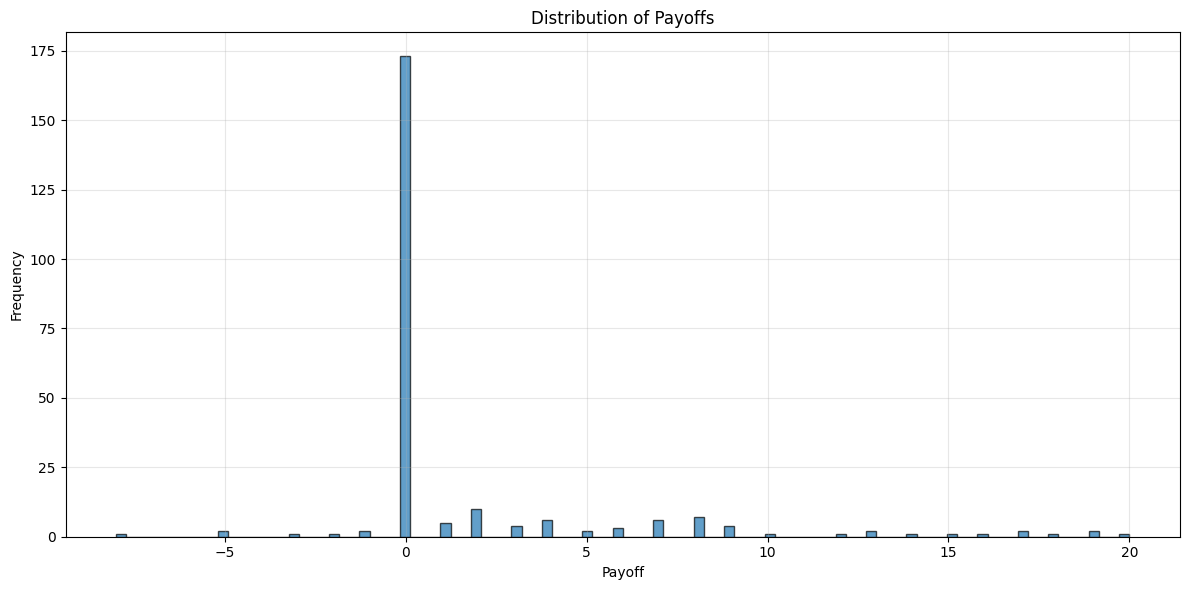

In [23]:
plt.figure(figsize=(12, 6))

# Create histogram
plt.hist(df_clean['payoff'], bins=100, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Payoffs')
plt.xlabel('Payoff')
plt.ylabel('Frequency')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

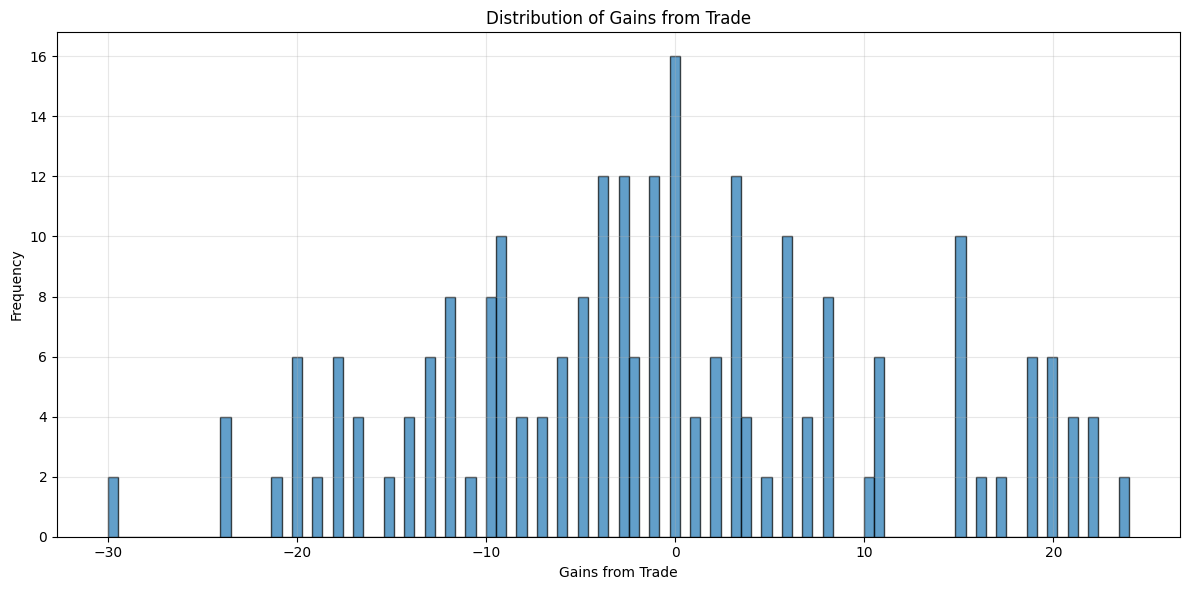

Number of gains from trade greater than 0: 94
Number of gains from trade less than 0: 130


In [24]:
plt.figure(figsize=(12, 6))

# Create histogram
plt.hist(df_clean['gains_from_trade'], bins=100, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Gains from Trade')
plt.xlabel('Gains from Trade')
plt.ylabel('Frequency')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and print the number of gains from trade greater than 0 and less than 0
greater_than_zero = (df_clean['gains_from_trade'] > 0).sum()
less_than_zero = (df_clean['gains_from_trade'] < 0).sum()

print(f"Number of gains from trade greater than 0: {greater_than_zero}")
print(f"Number of gains from trade less than 0: {less_than_zero}")

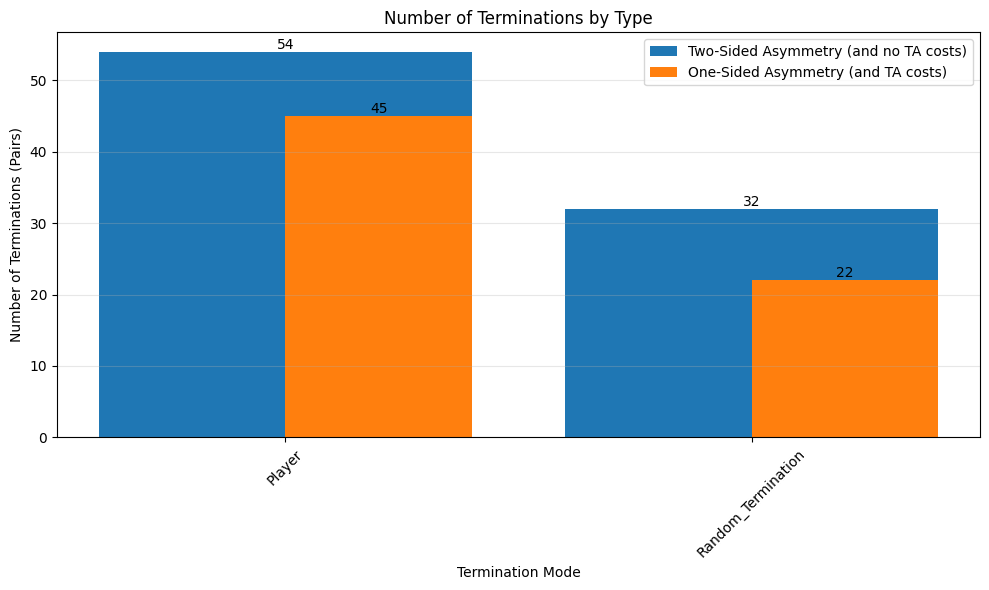

In [26]:
# Create the barplot
plt.figure(figsize=(10, 6))

# Get termination counts and divide by 2
termination_counts = df_clean['termination_mode'].value_counts() / 2

# Assuming df_one_sided_clean is defined and has a similar structure
termination_counts_one_sided = df_one_sided_clean['termination_mode'].value_counts() / 2

# Create the barplot
bars = plt.bar(termination_counts.index, termination_counts.values, label='Two-Sided Asymmetry (and no TA costs)')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}',
             ha='center', va='bottom')

# Plot numbers from df_one_sided_clean next to the existing bars
bars_one_sided = plt.bar(termination_counts_one_sided.index, termination_counts_one_sided.values, 
                         width=0.4, label='One-Sided Asymmetry (and TA costs)', align='edge')

# Add value labels on top of each bar for one-sided data
for bar in bars_one_sided:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}',
             ha='center', va='bottom')

# Customize the plot
plt.title('Number of Terminations by Type')
plt.xlabel('Termination Mode')
plt.ylabel('Number of Terminations (Pairs)')
plt.grid(True, axis='y', alpha=0.3)

# Rotate x-axis labels if needed
plt.xticks(rotation=45)

# Add legend
plt.legend()

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_34509/581477823.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 4
  plt.legend(handles=scatter.legend_elements()[0] + plt.gca().get_lines(), labels=['Seller', 'Buyer', 'Seller Regression', 'Buyer Regression'], title="Participant Role")


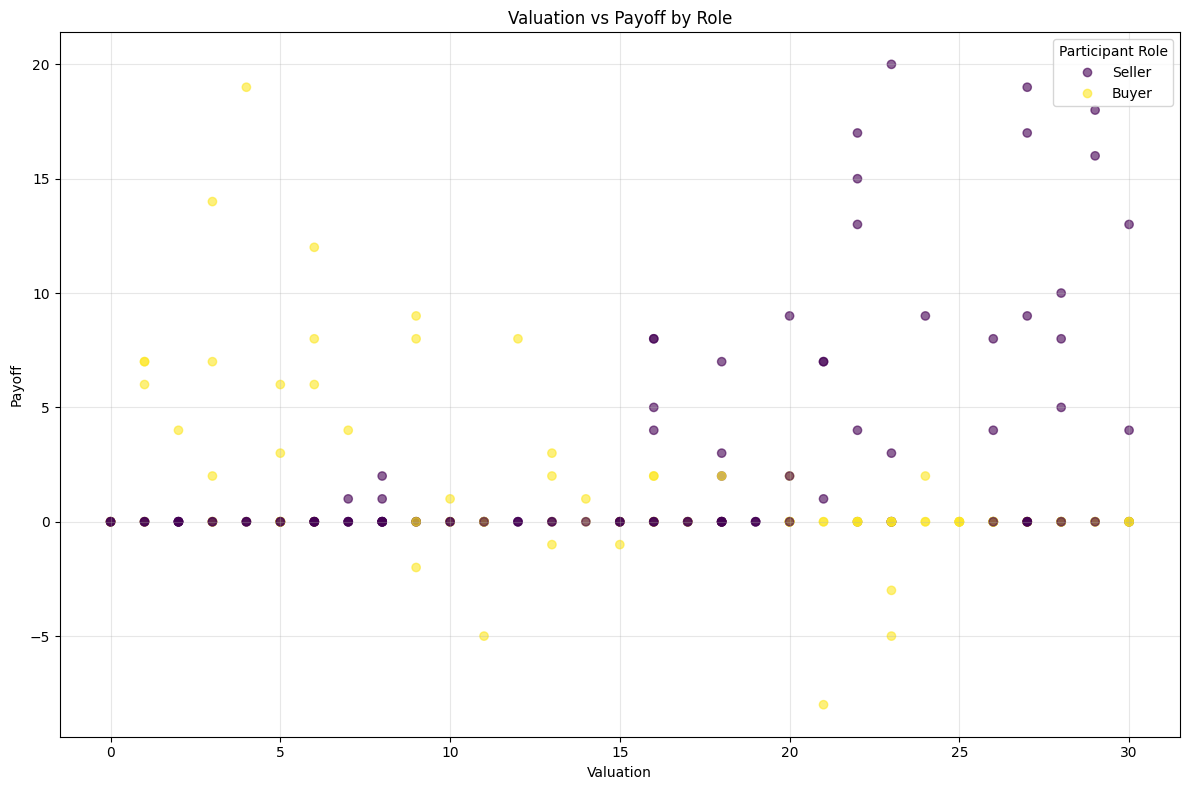

In [7]:
plt.figure(figsize=(12, 8))

# Add the scatter plot
scatter = plt.scatter(
    df_clean['valuation'],
    df_clean['payoff'],
    c=pd.Categorical(df_clean['participant_role']).codes,
    alpha=0.6
)


plt.title('Valuation vs Payoff by Role')
plt.xlabel('Valuation')
plt.ylabel('Payoff')
plt.grid(True, alpha=0.3)

plt.legend(handles=scatter.legend_elements()[0] + plt.gca().get_lines(), labels=['Seller', 'Buyer', 'Seller Regression', 'Buyer Regression'], title="Participant Role")

plt.tight_layout()
plt.show()

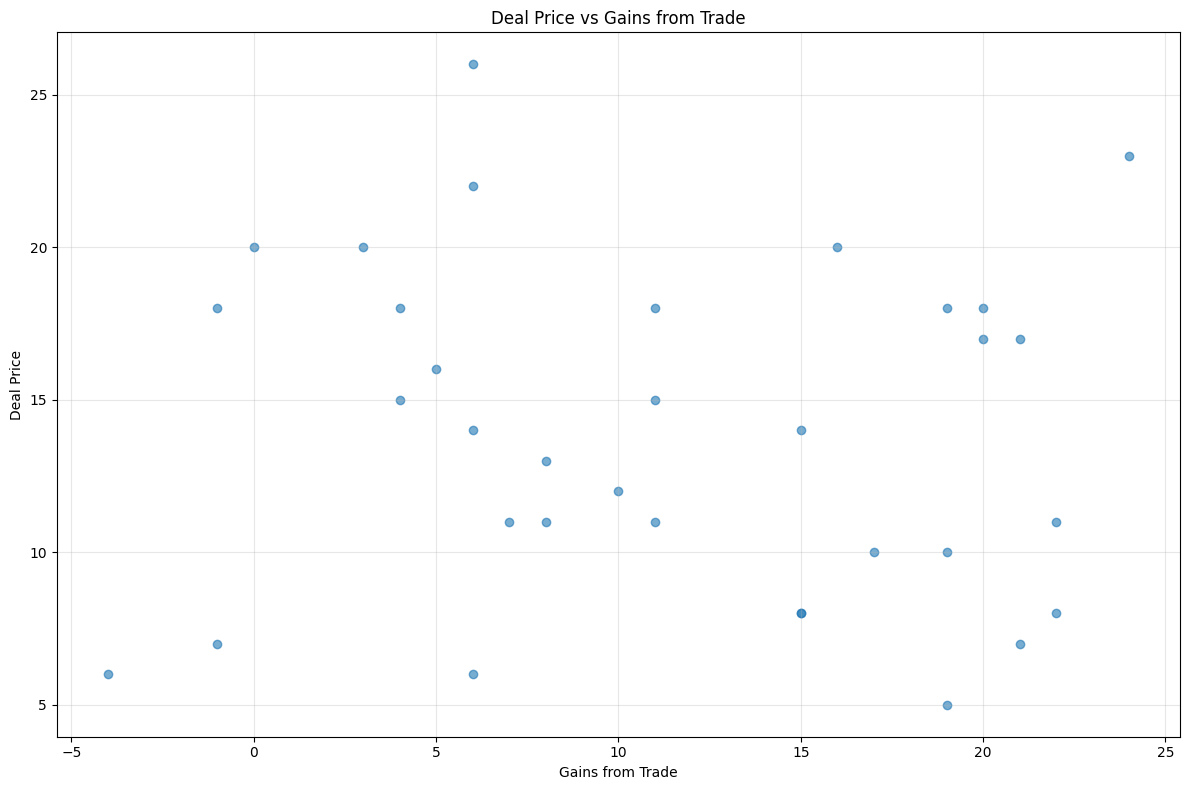

In [8]:
df_sellers = df_clean[df_clean['participant_role'] == 'Seller']

plt.figure(figsize=(12, 8))

# Add the scatter plot
scatter = plt.scatter(
    df_sellers['gains_from_trade'],
    df_sellers['deal_price'],
    alpha=0.6
)

plt.title('Deal Price vs Gains from Trade')
plt.xlabel('Gains from Trade')
plt.ylabel('Deal Price')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

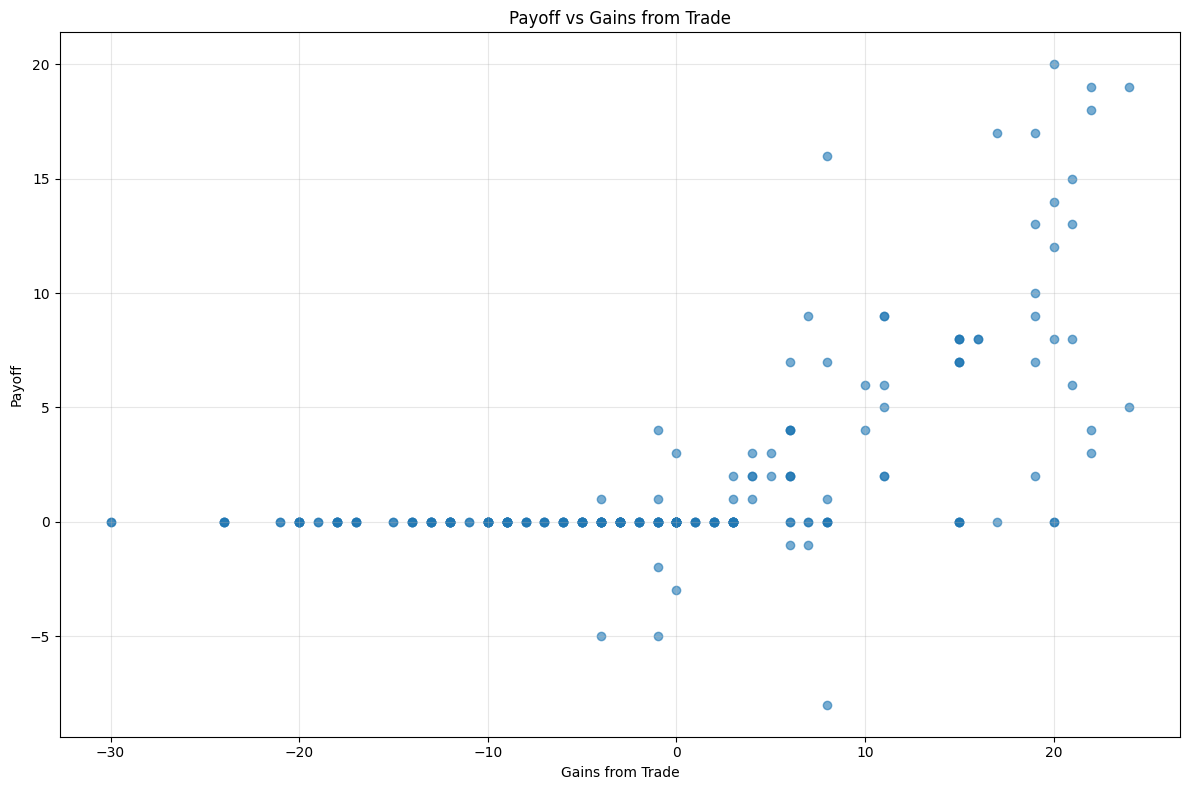

In [9]:
plt.figure(figsize=(12, 8))

# Add the scatter plot
scatter = plt.scatter(
    df_clean['gains_from_trade'],
    df_clean['payoff'],
    alpha=0.6
)

plt.title('Payoff vs Gains from Trade')
plt.xlabel('Gains from Trade')
plt.ylabel('Payoff')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_34509/581477823.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 4
  plt.legend(handles=scatter.legend_elements()[0] + plt.gca().get_lines(), labels=['Seller', 'Buyer', 'Seller Regression', 'Buyer Regression'], title="Participant Role")


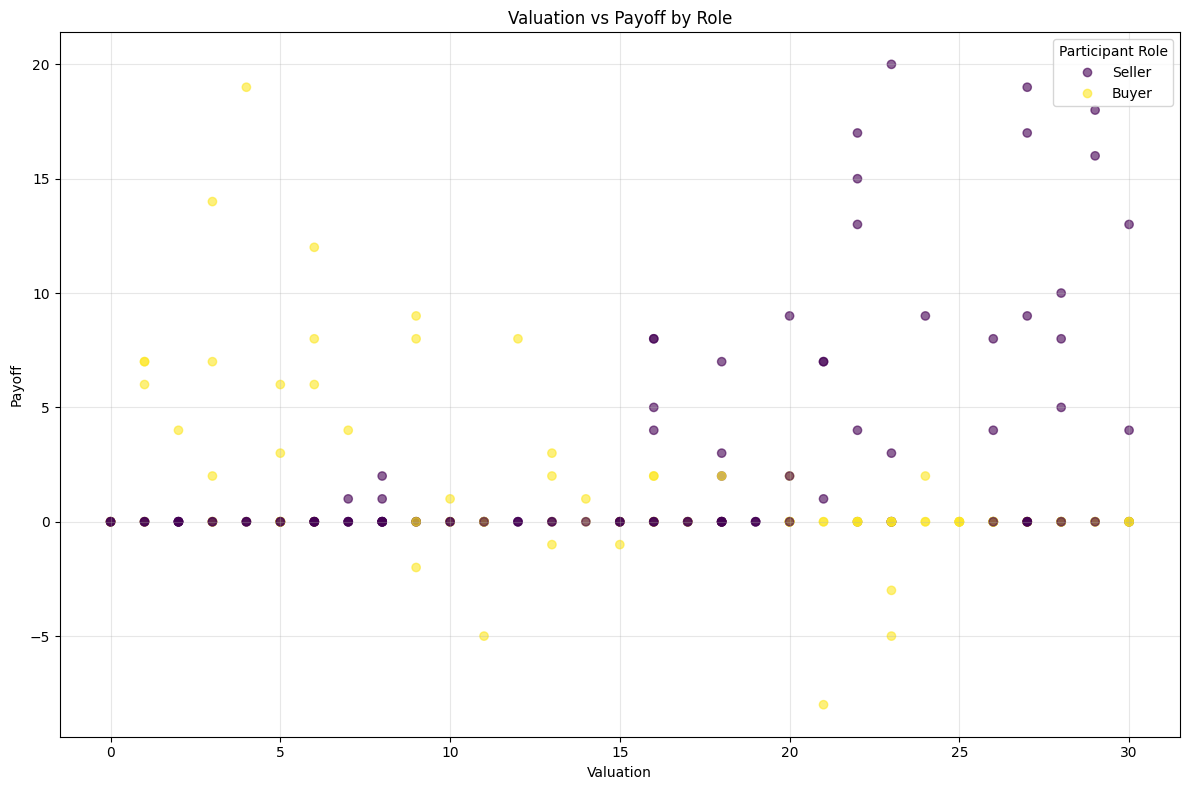

In [9]:
plt.figure(figsize=(12, 8))

# Add the scatter plot
scatter = plt.scatter(
    df_clean['valuation'],
    df_clean['payoff'],
    c=pd.Categorical(df_clean['participant_role']).codes,
    alpha=0.6
)


plt.title('Valuation vs Payoff by Role')
plt.xlabel('Valuation')
plt.ylabel('Payoff')
plt.grid(True, alpha=0.3)

plt.legend(handles=scatter.legend_elements()[0] + plt.gca().get_lines(), labels=['Seller', 'Buyer', 'Seller Regression', 'Buyer Regression'], title="Participant Role")

plt.tight_layout()
plt.show()

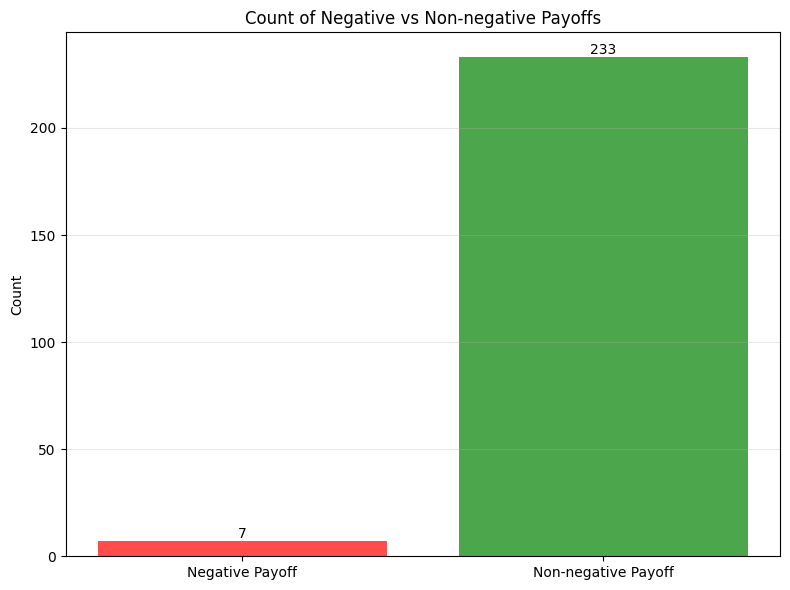

Percentage of negative payoffs: 2.92%
Percentage of non-negative payoffs: 97.08%


In [10]:
plt.figure(figsize=(8, 6))

# Create the counts
negative_count = (df_clean['payoff'] < 0).sum()
non_negative_count = (df_clean['payoff'] >= 0).sum()

# Create bar plot
plt.bar(['Negative Payoff', 'Non-negative Payoff'], 
        [negative_count, non_negative_count],
        color=['red', 'green'],
        alpha=0.7)

# Add value labels on top of each bar
for i, v in enumerate([negative_count, non_negative_count]):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Add labels and title
plt.title('Count of Negative vs Non-negative Payoffs')
plt.ylabel('Count')

# Add grid for better readability
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print the percentages
total = len(df_clean)
print(f"Percentage of negative payoffs: {(negative_count/total)*100:.2f}%")
print(f"Percentage of non-negative payoffs: {(non_negative_count/total)*100:.2f}%")

In [11]:
player_mistakes = df_clean[df_clean['payoff'] < 0]

ValueError: data type <class 'numpy.object_'> not inexact

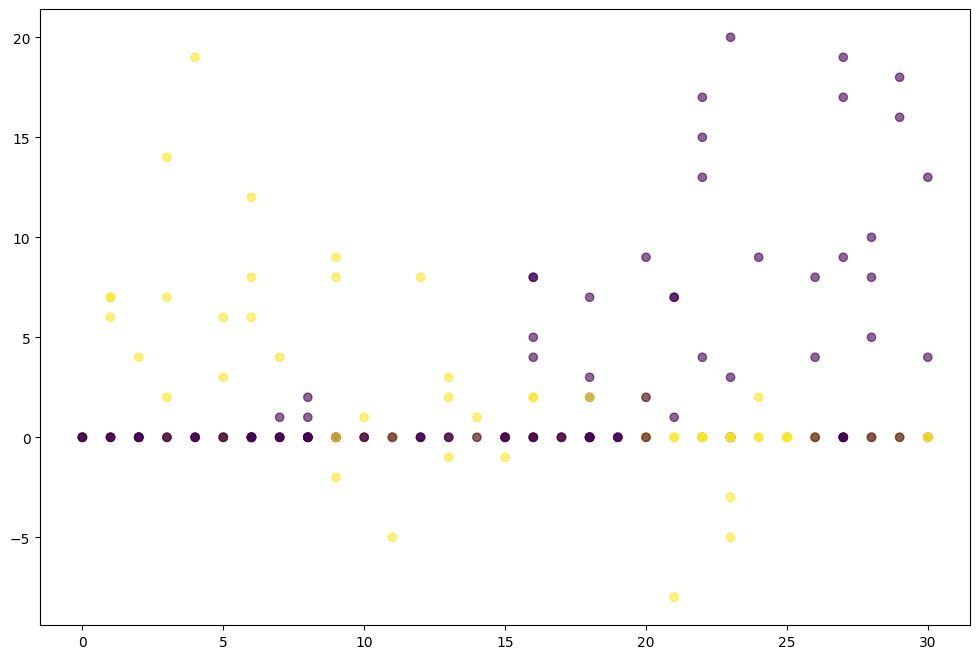

In [11]:
plt.figure(figsize=(12, 8))

# Add the scatter plot
scatter = plt.scatter(
    df_clean['valuation'],
    df_clean['payoff'],
    c=pd.Categorical(df_clean['participant_role']).codes,
    alpha=0.6
)

# Fit and plot regression lines for each role
for role in ['Buyer', 'Seller']:
    role_data = df_clean[df_clean['participant_role'] == role]
    slope, intercept = np.polyfit(role_data['valuation'], role_data['payoff'], 1)
    plt.plot(role_data['valuation'], slope * role_data['valuation'] + intercept, label=f'{role} Regression')

plt.title('Valuation vs Payoff by Role')
plt.xlabel('Valuation')
plt.ylabel('Payoff')
plt.grid(True, alpha=0.3)

plt.legend(handles=scatter.legend_elements()[0] + plt.gca().get_lines(), labels=['Seller', 'Buyer', 'Seller Regression', 'Buyer Regression'], title="Participant Role")

plt.tight_layout()
plt.show()

In [1]:
plt.figure(figsize=(12, 6))

# Create histogram
plt.hist(df_clean['split_gains_from_trade'], bins=30, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Split Gains from Trade')
plt.xlabel('Split Gains from Trade')
plt.ylabel('Frequency')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some basic statistics
print(f"Mean: {df_clean['split_gains_from_trade'].mean():.2f}")
print(f"Median: {df_clean['split_gains_from_trade'].median():.2f}")
print(f"Min: {df_clean['split_gains_from_trade'].min():.2f}")
print(f"Max: {df_clean['split_gains_from_trade'].max():.2f}")

NameError: name 'plt' is not defined

ValueError: data type <class 'numpy.object_'> not inexact

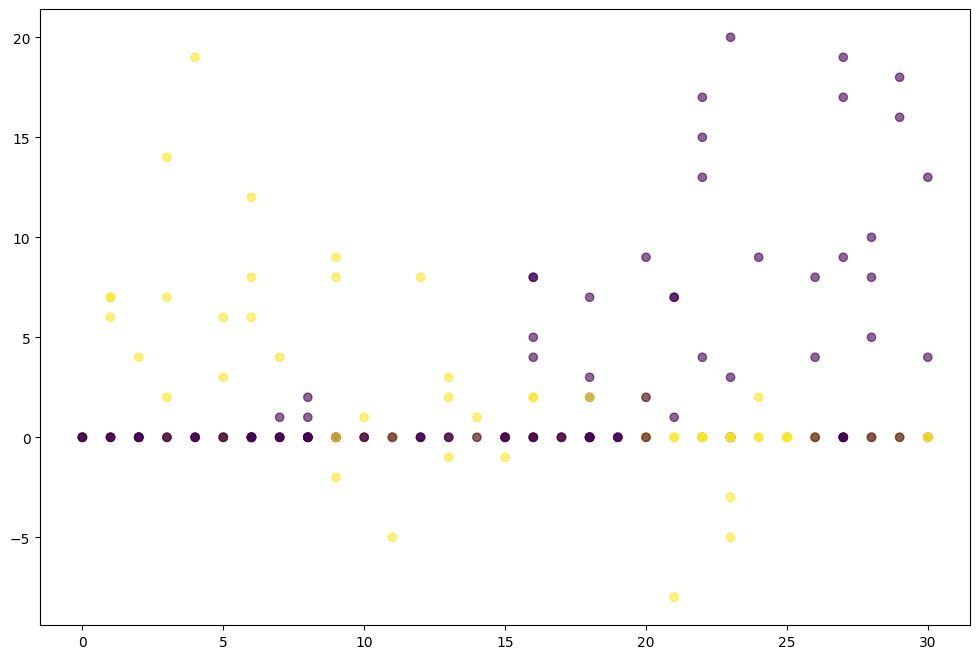

In [ ]:
plt.figure(figsize=(12, 8))

# Add the scatter plot
scatter = plt.scatter(
    df_clean['valuation'],
    df_clean['payoff'],
    c=pd.Categorical(df_clean['participant_role']).codes,
    alpha=0.6
)

# Fit and plot regression lines for each role
for role in ['Buyer', 'Seller']:
    role_data = df_clean[df_clean['participant_role'] == role]
    slope, intercept = np.polyfit(role_data['valuation'], role_data['payoff'], 1)
    plt.plot(role_data['valuation'], slope * role_data['valuation'] + intercept, label=f'{role} Regression')

plt.title('Valuation vs Payoff by Role')
plt.xlabel('Valuation')
plt.ylabel('Payoff')
plt.grid(True, alpha=0.3)

plt.legend(handles=scatter.legend_elements()[0] + plt.gca().get_lines(), labels=['Seller', 'Buyer', 'Seller Regression', 'Buyer Regression'], title="Participant Role")

plt.tight_layout()
plt.show()

ValueError: data type <class 'numpy.object_'> not inexact

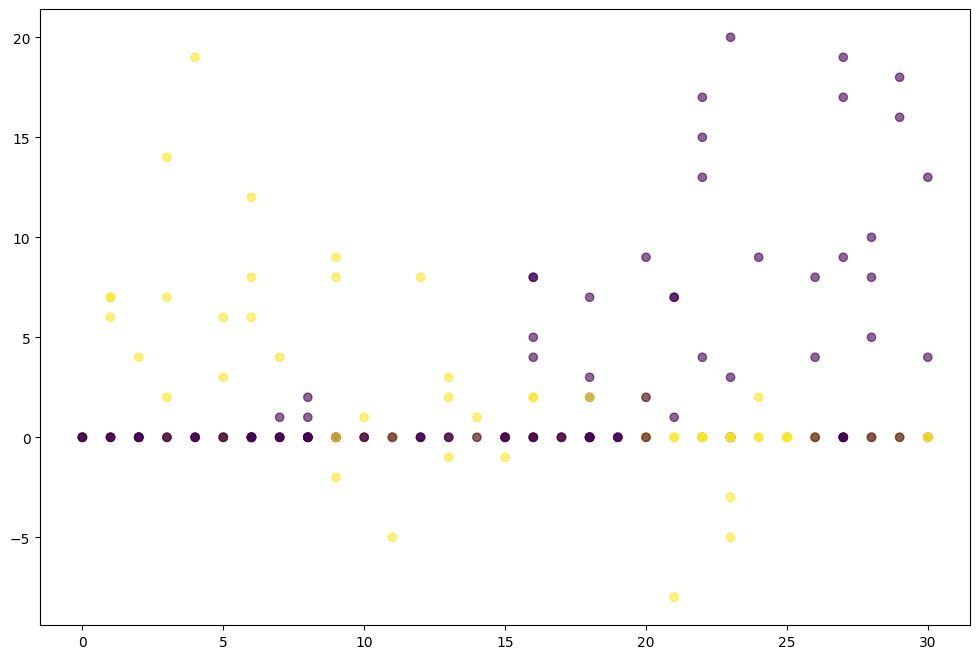

In [ ]:
plt.figure(figsize=(12, 8))

# Add the scatter plot
scatter = plt.scatter(
    df_clean['valuation'],
    df_clean['payoff'],
    c=pd.Categorical(df_clean['participant_role']).codes,
    alpha=0.6
)

# Fit and plot regression lines for each role
for role in ['Buyer', 'Seller']:
    role_data = df_clean[df_clean['participant_role'] == role]
    slope, intercept = np.polyfit(role_data['valuation'], role_data['payoff'], 1)
    plt.plot(role_data['valuation'], slope * role_data['valuation'] + intercept, label=f'{role} Regression')

plt.title('Valuation vs Payoff by Role')
plt.xlabel('Valuation')
plt.ylabel('Payoff')
plt.grid(True, alpha=0.3)

plt.legend(handles=scatter.legend_elements()[0] + plt.gca().get_lines(), labels=['Seller', 'Buyer', 'Seller Regression', 'Buyer Regression'], title="Participant Role")

plt.tight_layout()
plt.show()